In [1]:
from pathlib import Path
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
ROOT = PROJECT_ROOT / "data" / "runs" / "ca"

print("Notebook:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Data root:", ROOT, "exists:", ROOT.exists())


Notebook: C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\notebooks
Project root: C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project
Data root: C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\runs\ca exists: True


In [3]:
import re, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# we already have:
# NOTEBOOK_DIR = Path.cwd()
# PROJECT_ROOT = NOTEBOOK_DIR.parent
# ROOT = PROJECT_ROOT / "data" / "runs" / "ca"

TS_PAT = re.compile(r"\d{8}-\d{6}$")  # YYYYMMDD-HHMMSS at end of folder name

def infer_condition_from_dir(dirname: str) -> str:
    """'async_refractory_misclass_20251012-201502' → 'async_refractory_misclass'"""
    parts = dirname.split("_")
    if parts and TS_PAT.match(parts[-1]):
        return "_".join(parts[:-1]) or dirname
    return dirname

def list_batch_dirs(root: Path) -> list[Path]:
    """all subfolders that contain summary.csv or summary.json"""
    if not root.exists():
        raise FileNotFoundError(f"ROOT not found: {root}")
    dirs = []
    for d in root.iterdir():
        if d.is_dir() and ((d / "summary.csv").exists() or (d / "summary.json").exists()):
            dirs.append(d)
    # also scan deeper just in case
    for d in root.rglob("*"):
        if d.is_dir() and ((d / "summary.csv").exists() or (d / "summary.json").exists()):
            if d not in dirs:
                dirs.append(d)
    return sorted(dirs, key=lambda p: p.name)

def load_one_batch_dir(d: Path) -> pd.DataFrame:
    """
    Load ONE batch folder into per-run rows.
    Prefers summary.csv; falls back to summary.json (supports {"runs":[...]})
    Returns columns: condition, run_idx, reach_fake_pct, reach_real_pct, peak_fake, peak_real, source
    """
    cond = infer_condition_from_dir(d.name)
    csvp, jsp = d / "summary.csv", d / "summary.json"

    if csvp.exists():
        df = pd.read_csv(csvp)
    elif jsp.exists():
        obj = json.loads(jsp.read_text(encoding="utf-8", errors="ignore"))
        if isinstance(obj, dict) and isinstance(obj.get("runs"), list):
            df = pd.DataFrame(obj["runs"])
        else:
            df = pd.json_normalize(obj)
    else:
        return pd.DataFrame()

    # normalize column names seen in your logs/CSVs
    rename = {
        "run":"run_idx",
        "reachF":"reach_fake_pct", "reach_fake":"reach_fake_pct",
        "reachR":"reach_real_pct", "reach_real":"reach_real_pct",
        "peak_f":"peak_fake", "peak_r":"peak_real",
        "t_peak_f":"t_peak_fake", "t_peak_r":"t_peak_real",
        "total_shares_f":"total_shares_fake", "total_shares_r":"total_shares_real",
    }
    df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})

    # ensure required columns exist
    if "run_idx" not in df.columns:
        df["run_idx"] = np.arange(1, len(df)+1)
    for c in ["reach_fake_pct","reach_real_pct","peak_fake","peak_real"]:
        if c not in df.columns:
            df[c] = np.nan

    # drop duplicate column names if any
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df["condition"] = cond
    df["source"] = str(d.relative_to(ROOT))
    return df[["condition","run_idx","reach_fake_pct","reach_real_pct","peak_fake","peak_real","source"]]

def load_phase(prefixes: list[str]) -> pd.DataFrame:
    """
    Keep batch folders whose **condition** startswith any given prefix.
    (conditions are the folder name minus the trailing timestamp)
    """
    frames = []
    for d in list_batch_dirs(ROOT):
        cond = infer_condition_from_dir(d.name).lower()
        if any(cond.startswith(p.lower()) for p in prefixes):
            df = load_one_batch_dir(d)
            if not df.empty:
                frames.append(df)
    if not frames:
        print("⚠️ Nothing loaded for", prefixes)
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True, sort=False)
    out = out.loc[:, ~out.columns.duplicated()].copy()
    out = out.sort_values(["condition","run_idx"]).reset_index(drop=True)
    print(f"Loaded {len(out)} rows | Conditions:", out["condition"].unique().tolist())
    return out

# tiny helper for dot plots (avoids overlapping)
def jittered_x(categories: pd.Series):
    rng = np.random.default_rng(42)
    names = pd.Index(sorted(pd.unique(categories)))
    xmap = {n:i for i,n in enumerate(names)}
    xs = np.array([xmap[c] for c in categories], float)
    xs += rng.normal(0, 0.06, len(xs))
    return xs, list(names)

def se(x):
    x = pd.Series(x).dropna()
    return x.std(ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0.0


In [4]:
def plot_condition_all(fig_root: Path, df_cond: pd.DataFrame, cond_label: str):
    """
    For one condition, create a subfolder and save:
      - line plots over run_idx: reach_fake, reach_real, peak_fake, peak_real
      - histograms for the same metrics
    """
    outdir = fig_root / cond_label
    outdir.mkdir(parents=True, exist_ok=True)

    # ---- LINE PLOTS (x = run_idx)
    def lineplot(ycol: str, title: str, fname: str, ylabel: str):
        plt.figure()
        sub = df_cond.sort_values("run_idx")
        plt.plot(sub["run_idx"], sub[ycol], marker="o", linestyle="-")
        plt.xlabel("Run index (1..N)")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.tight_layout()
        plt.savefig(outdir / fname, dpi=200)
        plt.show()

    # ---- HISTOGRAMS (distribution across runs)
    def histplot(ycol: str, title: str, fname: str, xlabel: str, bins=10):
        plt.figure()
        plt.hist(df_cond[ycol].dropna().values, bins=bins)
        plt.xlabel(xlabel)
        plt.ylabel("Count of runs")
        plt.title(title)
        plt.tight_layout()
        plt.savefig(outdir / fname, dpi=200)
        plt.show()

    # Reach Fake
    lineplot("reach_fake_pct",
             f"{cond_label} — Reach Fake (%) across runs",
             "line_reach_fake.png", "Reach Fake (%)")
    histplot("reach_fake_pct",
             f"{cond_label} — Reach Fake (%) distribution",
             "hist_reach_fake.png", "Reach Fake (%)")

    # Reach Real
    lineplot("reach_real_pct",
             f"{cond_label} — Reach Real (%) across runs",
             "line_reach_real.png", "Reach Real (%)")
    histplot("reach_real_pct",
             f"{cond_label} — Reach Real (%) distribution",
             "hist_reach_real.png", "Reach Real (%)")

    # Peaks (optional but useful)
    lineplot("peak_fake",
             f"{cond_label} — Peak Fake across runs",
             "line_peak_fake.png", "Peak Fake")
    histplot("peak_fake",
             f"{cond_label} — Peak Fake distribution",
             "hist_peak_fake.png", "Peak Fake")

    lineplot("peak_real",
             f"{cond_label} — Peak Real across runs",
             "line_peak_real.png", "Peak Real")
    histplot("peak_real",
             f"{cond_label} — Peak Real distribution",
             "hist_peak_real.png", "Peak Real")

def export_summary_table(fig_root: Path, df: pd.DataFrame, tag: str):
    """Save per-condition mean ± SE for key metrics."""
    g = (df.groupby("condition", as_index=False)
           .agg(reach_fake_mean=("reach_fake_pct","mean"),
                reach_fake_se=("reach_fake_pct", se),
                reach_real_mean=("reach_real_pct","mean"),
                reach_real_se=("reach_real_pct", se),
                peak_fake_mean=("peak_fake","mean"),
                peak_fake_se=("peak_fake", se),
                peak_real_mean=("peak_real","mean"),
                peak_real_se=("peak_real", se)))
    g.to_csv(fig_root / f"{tag}_summary_means_se.csv", index=False)
    return g


In [5]:
FIGDIR = PROJECT_ROOT / "figures" / "phase3"
FIGDIR.mkdir(parents=True, exist_ok=True)
print("Saving to:", FIGDIR)

PHASE_PREFIXES = [
    "spatial",
    "async_refractory_misclass_hetero_spatial",
]
df = load_phase(PHASE_PREFIXES)
df.head()


Saving to: C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\figures\phase3
Loaded 60 rows | Conditions: ['async_refractory_misclass_hetero_spatial', 'spatial']


,condition,run_idx,reach_fake_pct,reach_real_pct,peak_fake,peak_real,source
0,async_refractory_misclass_hetero_spatial,1,0.8976,1.0,685,2316,async_refractory_misclass_hetero_spatial_20251...
1,async_refractory_misclass_hetero_spatial,2,0.9372,1.0,829,2265,async_refractory_misclass_hetero_spatial_20251...
2,async_refractory_misclass_hetero_spatial,3,0.8960,1.0,629,2301,async_refractory_misclass_hetero_spatial_20251...
3,async_refractory_misclass_hetero_spatial,4,0.8912,1.0,643,2295,async_refractory_misclass_hetero_spatial_20251...
4,async_refractory_misclass_hetero_spatial,5,0.8692,1.0,496,2313,async_refractory_misclass_hetero_spatial_20251...


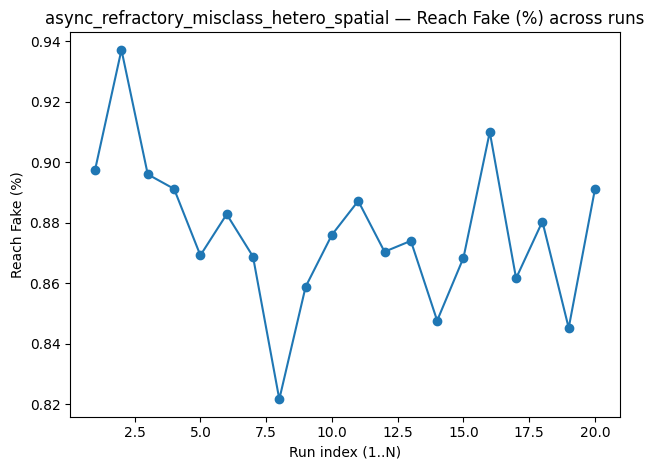

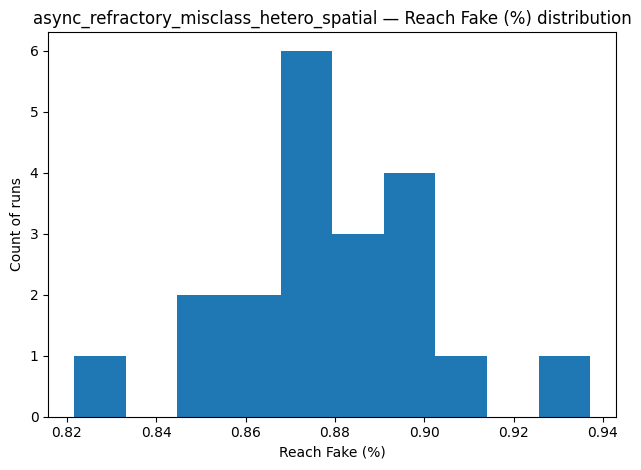

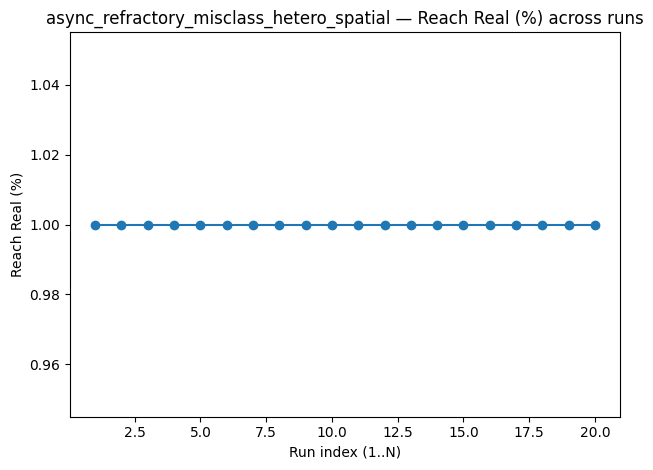

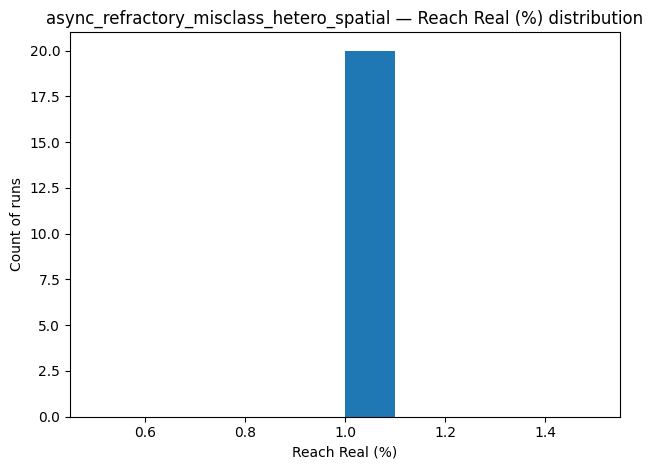

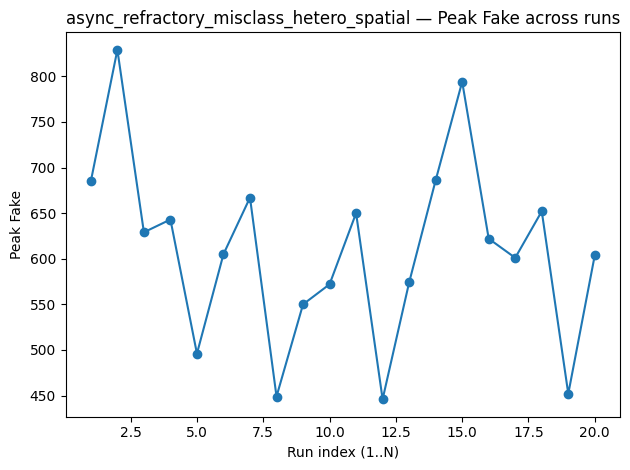

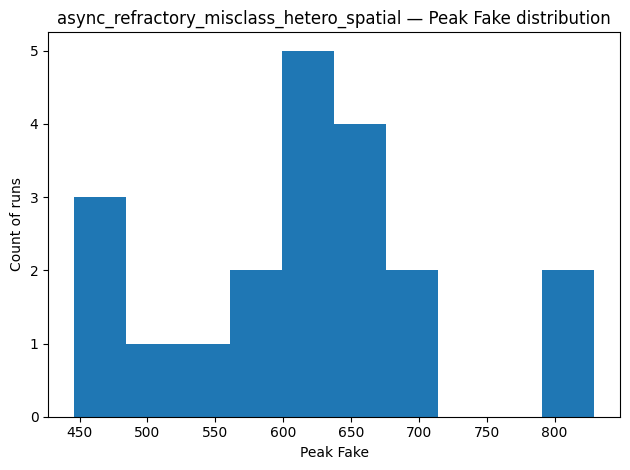

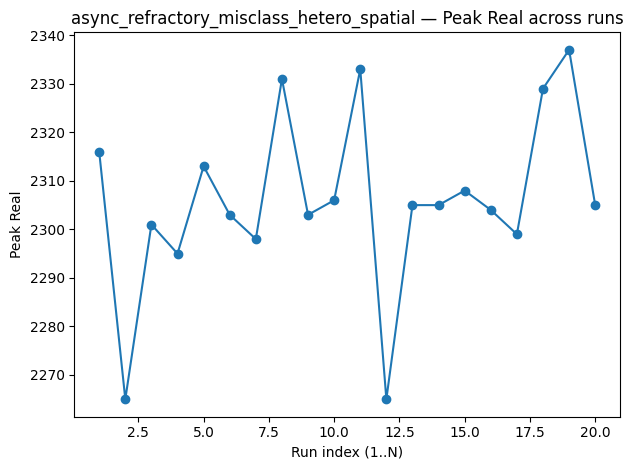

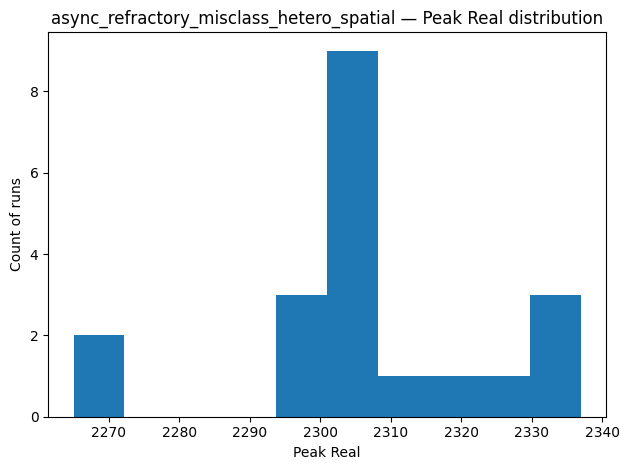

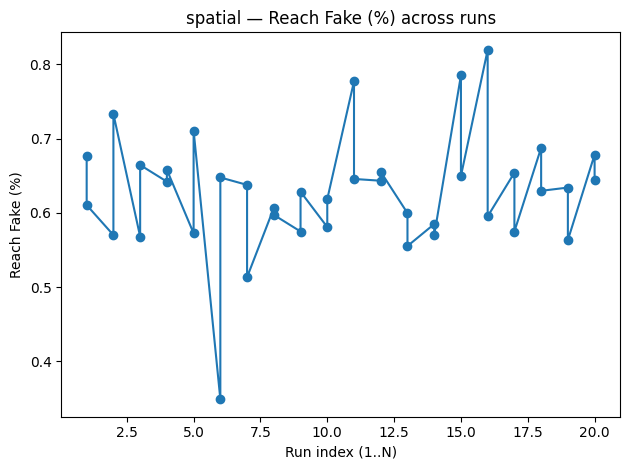

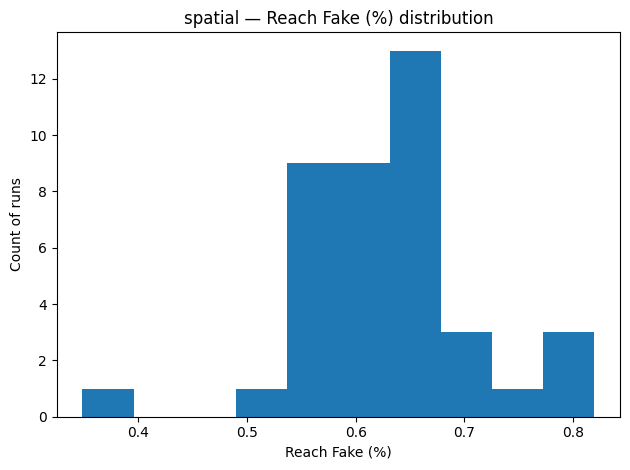

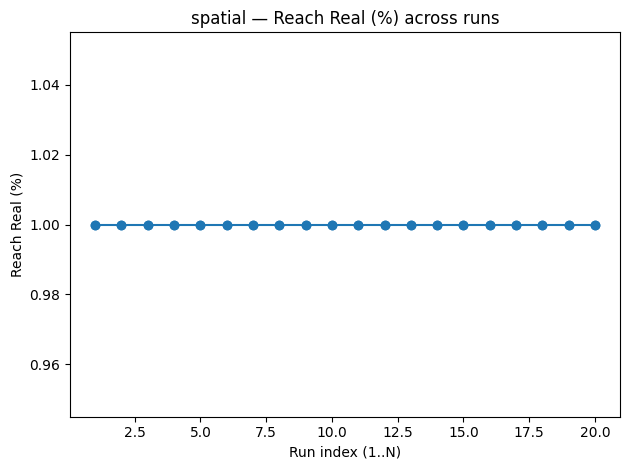

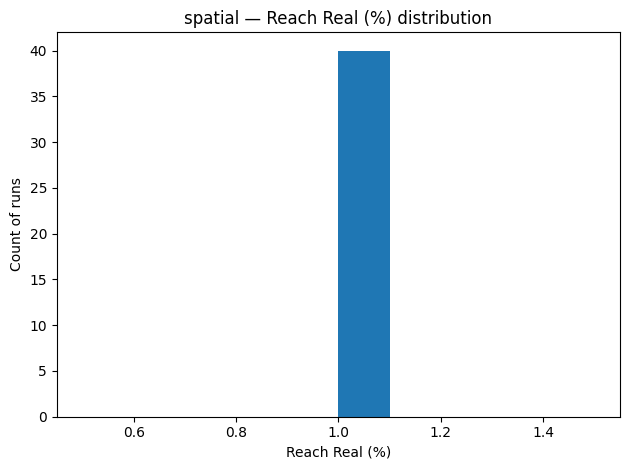

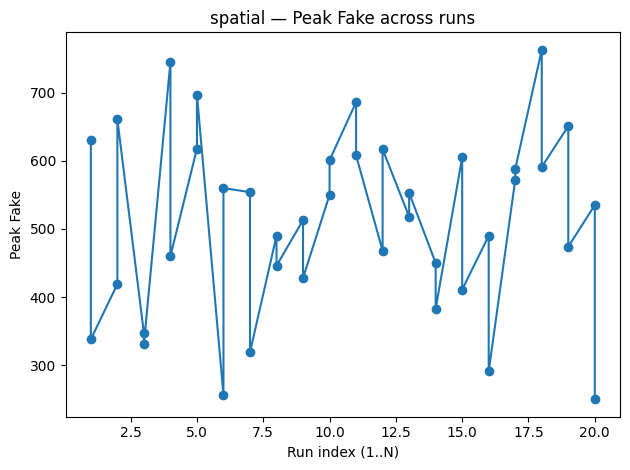

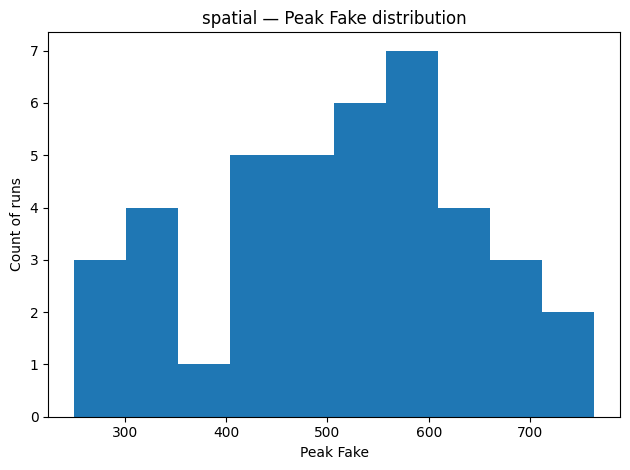

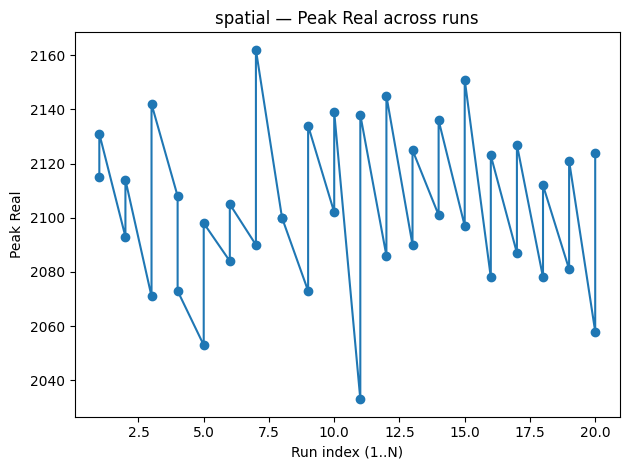

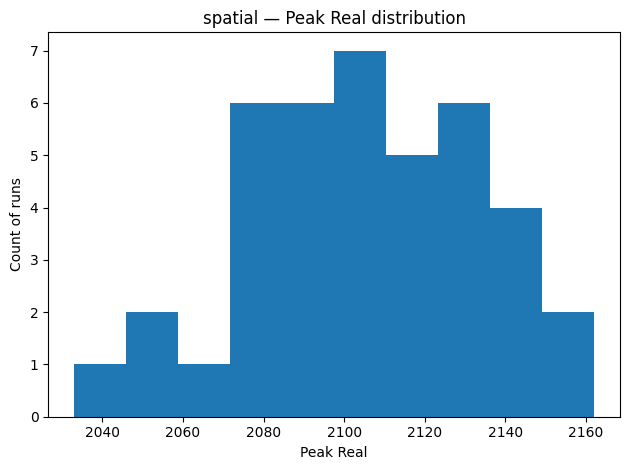

In [6]:
if df.empty:
    print("No Phase 3 data found")
else:
    for cond in sorted(df["condition"].unique()):
        plot_condition_all(FIGDIR, df[df["condition"]==cond], cond)
    summary = export_summary_table(FIGDIR, df, "phase3")
    summary
